In [ ]:
import random

import pandas as pd
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler,autocast
from torchvision import transforms, models

from tqdm import tqdm

In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:",device)

Using: cuda


In [ ]:
df=pd.read_csv("../data/NIH Sample/sample_labels.csv")

df['Finding Labels']=df['Finding Labels'].apply(lambda x: x.split('|'))

all_labels=sorted(list({l for sublist in df['Finding Labels'] for l in sublist}))
label_map={label: i for i, label in enumerate(all_labels)}

def encode_labels(labels):
    vec=np.zeros(len(all_labels))
    for l in labels:
        vec[label_map[l]]=1
    return vec

df['encoded']=df['Finding Labels'].apply(encode_labels)

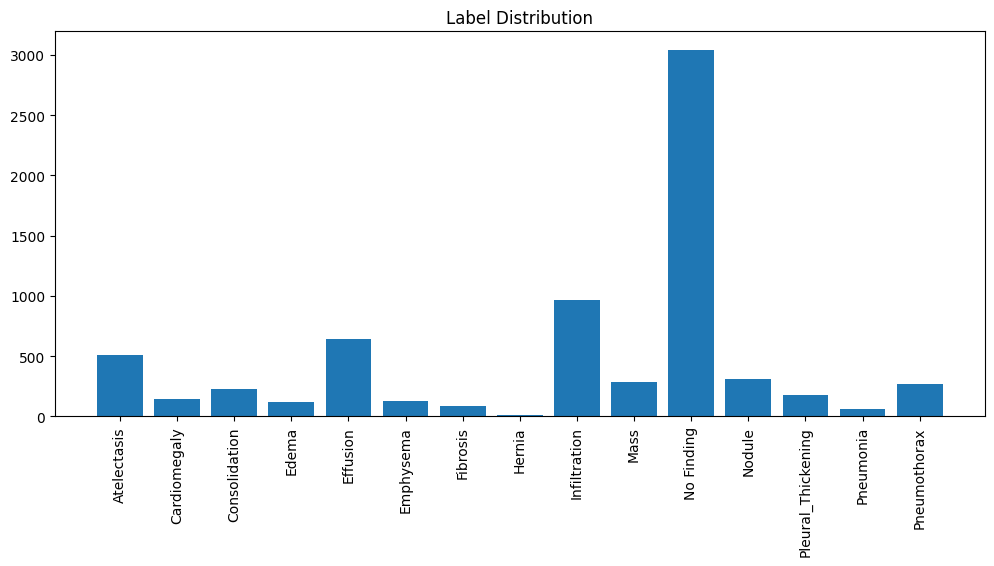

In [ ]:
label_counts=np.zeros(len(all_labels))

for labels in df['encoded']:
    label_counts+=labels

plt.figure(figsize=(12,5))
plt.bar(all_labels,label_counts)
plt.xticks(rotation=90)
plt.title("Label Distribution")
plt.show()

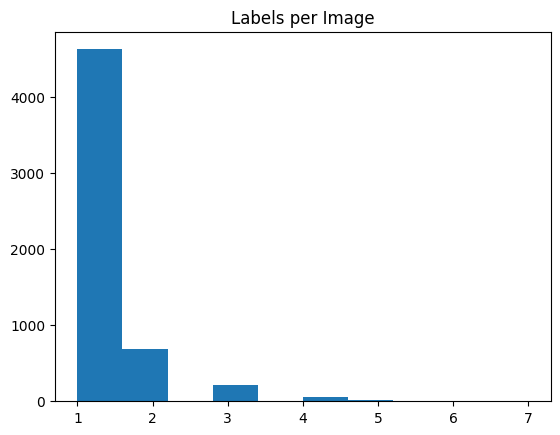

In [ ]:
num_labels_per_image=[sum(x) for x in df['encoded']]

plt.hist(num_labels_per_image,bins=10)
plt.title("Labels per Image")
plt.show()

In [ ]:
train_df,val_df=train_test_split(df, test_size=0.2,random_state=42)

In [ ]:
class ChestXrayDataset(Dataset):
    def __init__(self, df,img_dir,transform=None):
        self.df=df
        self.img_dir=img_dir
        self.transform=transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name=self.df.iloc[idx]['Image Index']
        img_path=os.path.join(self.img_dir,img_name)

        image=Image.open(img_path).convert("RGB")
        label=torch.tensor(self.df.iloc[idx]['encoded'],dtype=torch.float32)

        if self.transform:
            image=self.transform(image)

        return image,label

In [ ]:
train_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomResizedCrop(224,scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [ ]:
train_dataset=ChestXrayDataset(train_df,"../data/NIH Sample/sample/images",train_transform)
val_dataset=ChestXrayDataset(val_df,"../data/NIH Sample/sample/images",val_transform)

train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=32,shuffle=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0256994].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.08956].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.058823526..1.0616211].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.045656].


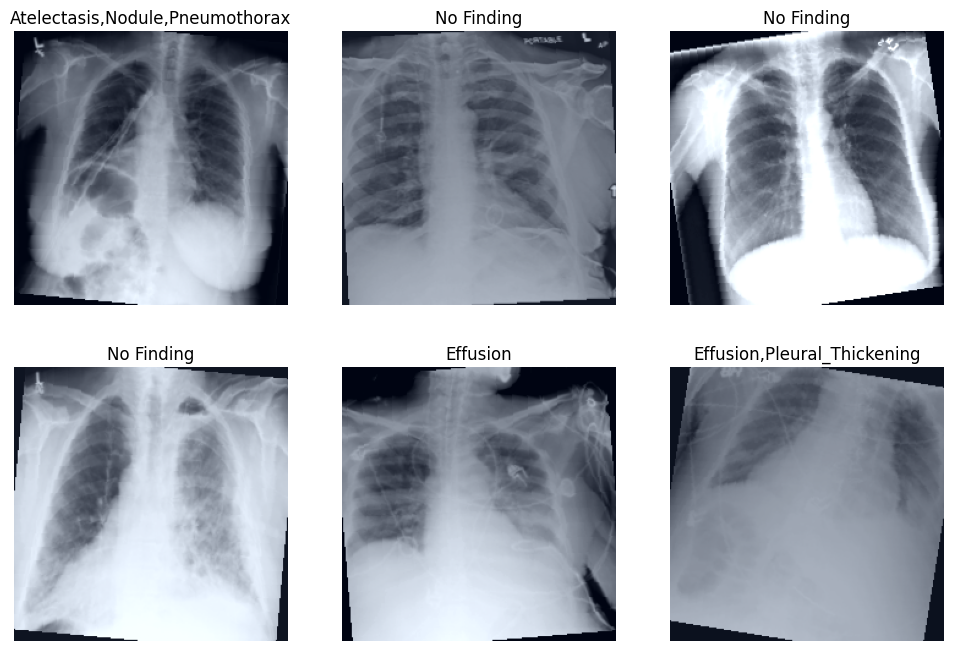

In [ ]:
plt.figure(figsize=(12,8))

for i in range(6):
    idx=random.randint(0,len(train_dataset)-1)
    image,label=train_dataset[idx]

    img=image.permute(1,2,0).numpy()
    img=(img*0.229+0.485)

    labels=[all_labels[j] for j in range(len(label)) if label[j]==1]

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(",".join(labels))
    plt.axis("off")

plt.show()

In [ ]:
labels_matrix=np.stack(df['encoded'].values)

pos_counts=labels_matrix.sum(axis=0)
neg_counts=len(labels_matrix)-pos_counts

pos_weight=torch.tensor(neg_counts/(pos_counts+1e-5),dtype=torch.float32).to(device)

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self,gamma=2,alpha=None):
        super().__init__()
        self.gamma=gamma
        self.alpha=alpha

    def forward(self,logits,targets):
        bce=nn.functional.binary_cross_entropy_with_logits(logits,targets,reduction='none')

        probs=torch.sigmoid(logits)
        pt=torch.where(targets==1,probs,1-probs)

        loss=(1-pt)**self.gamma*bce

        if self.alpha is not None:
            loss=self.alpha*loss

        return loss.mean()

In [ ]:
model=models.efficientnet_b0(pretrained=True)

num_features=model.classifier[1].in_features
model.classifier[1]=nn.Linear(num_features,len(all_labels))

model=model.to(device)

In [ ]:
criterion=FocalLoss(gamma=2)
optimizer=torch.optim.Adam(model.parameters(),lr=1e-4)
use_amp=device.type=="cuda"
scaler=GradScaler(device="cuda") if use_amp else None

In [ ]:
def find_best_thresholds(y_true,y_pred):
    thresholds=np.linspace(0.05,0.5,20)
    best_thresholds=[]

    for i in range(y_true.shape[1]):
        best_f1=0
        best_t=0.5

        for t in thresholds:
            preds=(y_pred[:,i]>t).astype(int)
            f1=f1_score(y_true[:,i],preds)

            if f1>best_f1:
                best_f1=f1
                best_t=t

        best_thresholds.append(best_t)

    return np.array(best_thresholds)

In [ ]:
def evaluate(model,loader):
    model.eval()
    all_targets,all_outputs=[],[]

    with torch.no_grad():
        for images,labels in loader:
            images=images.to(device)
            labels=labels.to(device)

            outputs=model(images)
            probs=torch.sigmoid(outputs)

            all_targets.append(labels.cpu().numpy())
            all_outputs.append(probs.cpu().numpy())

    y_true=np.vstack(all_targets)
    y_pred=np.vstack(all_outputs)

    thresholds=find_best_thresholds(y_true,y_pred)
    y_pred_bin=(y_pred>thresholds).astype(int)

    f1=f1_score(y_true,y_pred_bin,average="macro")
    auc=roc_auc_score(y_true,y_pred,average="macro")

    return f1,auc

In [ ]:
epochs=10
best_auc=0

train_losses,val_f1s,val_aucs=[],[],[]

for epoch in range(epochs):
    model.train()
    total_loss=0

    if epoch==3:
        for param in model.features.parameters():
            param.requires_grad=True

    loop=tqdm(train_loader,desc=f"Epoch {epoch+1}")

    for images,labels in loop:
        images=images.to(device)
        labels=labels.to(device)

        if use_amp:
            with autocast(device_type="cuda"):
                outputs=model(images)
                loss=criterion(outputs,labels)

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs=model(images)
            loss=criterion(outputs,labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss+=loss.item()
        loop.set_postfix(loss=loss.item())

    avg_loss=total_loss/len(train_loader)
    val_f1,val_auc=evaluate(model,val_loader)

    train_losses.append(avg_loss)
    val_f1s.append(val_f1)
    val_aucs.append(val_auc)

    if val_auc>best_auc:
        best_auc=val_auc
        torch.save(model.state_dict(),"models/best_model.pth")

    print(f"\nEpoch {epoch+1}")
    print(f"Loss: {avg_loss:.4f}")
    print(f"Val F1: {val_f1:.4f} | Val AUC: {val_auc:.4f}")

Epoch 1: 100%|██████████| 141/141 [04:58<00:00,  2.12s/it, loss=0.0342]



Epoch 1
Loss: 0.0721
Val F1: 0.1774 | Val AUC: 0.6411


Epoch 2: 100%|██████████| 141/141 [05:04<00:00,  2.16s/it, loss=0.0434]



Epoch 2
Loss: 0.0556
Val F1: 0.1953 | Val AUC: 0.6658


Epoch 3: 100%|██████████| 141/141 [05:01<00:00,  2.14s/it, loss=0.0262]


...


Epoch 8
Loss: 0.0474
Val F1: 0.2421 | Val AUC: 0.7399


Epoch 9: 100%|██████████| 141/141 [05:31<00:00,  2.35s/it, loss=0.0731]



Epoch 9
Loss: 0.0463
Val F1: 0.2449 | Val AUC: 0.7348


Epoch 10: 100%|██████████| 141/141 [05:03<00:00,  2.16s/it, loss=0.12]  



Epoch 10
Loss: 0.0451
Val F1: 0.2530 | Val AUC: 0.7374


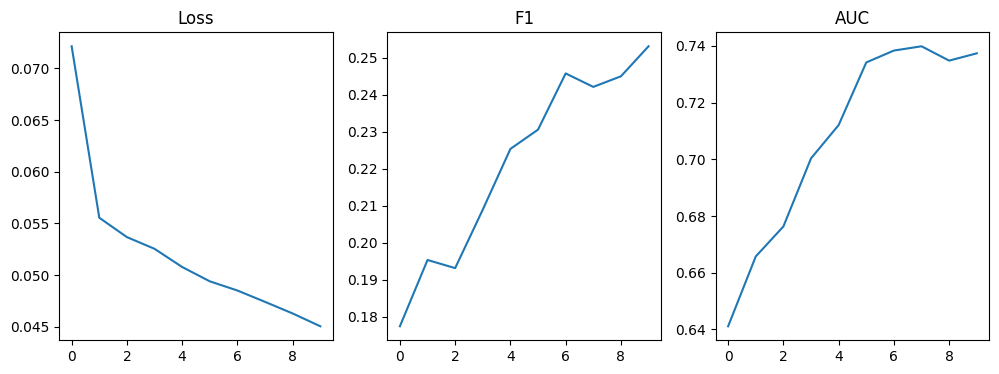

In [109]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(train_losses)
plt.title("Loss")

plt.subplot(1,3,2)
plt.plot(val_f1s)
plt.title("F1")

plt.subplot(1,3,3)
plt.plot(val_aucs)
plt.title("AUC")

plt.show()

In [ ]:
model.eval()
all_targets,all_outputs=[],[]

with torch.no_grad():
    for images,labels in val_loader:
        images=images.to(device)
        outputs=model(images)
        probs=torch.sigmoid(outputs)
        
        all_targets.append(labels.cpu().numpy())
        all_outputs.append(probs.cpu().numpy())

y_true=np.vstack(all_targets)
y_pred=np.vstack(all_outputs)

threshold=0.2
y_pred_bin=(y_pred>threshold).astype(int)

def per_sample_accuracy(y_true,y_pred_bin):
    return (y_true==y_pred_bin).mean(axis=1).mean()

def per_class_accuracy(y_true,y_pred_bin):
    return (y_true==y_pred_bin).mean(axis=0)

overall_acc=per_sample_accuracy(y_true,y_pred_bin)
class_acc=per_class_accuracy(y_true,y_pred_bin)

print("Overall accuracy:",overall_acc)
for i,acc in enumerate(class_acc):
    print(f"{all_labels[i]}: {acc:.3f}")

Overall accuracy: 0.6864527629233512
Atelectasis: 0.408
Cardiomegaly: 0.864
Consolidation: 0.688
Edema: 0.874
Effusion: 0.547
Emphysema: 0.833
Fibrosis: 0.881
Hernia: 0.996
Infiltration: 0.239
Mass: 0.673
No Finding: 0.540
Nodule: 0.448
Pleural_Thickening: 0.758
Pneumonia: 0.941
Pneumothorax: 0.607


In [110]:
features=[]
gradients=[]

def forward_hook(module,input,output):
    features.append(output)

def backward_hook(module,grad_input,grad_output):
    gradients.append(grad_output[0])

target_layer=model.features[-1]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

In [111]:
def decode_labels(vec,threshold=0.5):
    return [all_labels[i] for i, v in enumerate(vec) if v>=threshold]

In [ ]:
def generate_gradcam_pp(image,model,class_idx):
    model.eval()
    features.clear()
    gradients.clear()

    image=image.unsqueeze(0).to(device)

    output=model(image)
    model.zero_grad()
    output[0,class_idx].backward()

    grads=gradients[0].detach().cpu().numpy()[0]
    fmap=features[0].detach().cpu().numpy()[0]

    grads_sq=grads**2
    grads_cube=grads**3
    eps=1e-8

    alpha=grads_sq/(2*grads_sq+np.sum(fmap*grads_cube,axis=(1,2),keepdims=True)+eps)
    weights=np.sum(alpha*np.maximum(grads,0),axis=(1,2))

    cam=np.zeros(fmap.shape[1:],dtype=np.float32)

    for i,w in enumerate(weights):
        cam+=w*fmap[i]

    cam=np.maximum(cam,0)
    cam=cv2.resize(cam,(224,224))
    cam=cam-cam.min()
    cam=cam/(cam.max()+1e-8)

    return cam

In [113]:
def show_predictions_with_gradcam(image, true_label, probs, threshold=0.2):
    img = image.permute(1,2,0).cpu().numpy()
    img = (img * 0.229 + 0.485)

    true_labels = [all_labels[i] for i, v in enumerate(true_label) if v == 1]

    pred_classes = np.where(probs > threshold)[0]
    pred_labels = [(all_labels[i], probs[i]) for i in pred_classes]

    print("TRUE LABELS:")
    print(", ".join(true_labels))

    print("\nPREDICTIONS:")
    for label, p in pred_labels:
        print(f"{label}: {p:.2f}")

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")
    plt.show()

    for c, p in pred_labels:
        idx = all_labels.index(c)

        cam = generate_gradcam_pp(image, model, idx)

        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET) / 255.0
        overlay = 0.6 * img + 0.4 * heatmap

        plt.figure(figsize=(10,4))

        plt.subplot(1,3,1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(cam, cmap="jet")
        plt.title(f"Grad-CAM++ ({c})")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(overlay)
        plt.title(f"Overlay ({p:.2f})")
        plt.axis("off")

        plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0296907].


TRUE LABELS:
No Finding

PREDICTIONS:
Atelectasis: 0.22
Emphysema: 0.23
Infiltration: 0.35
No Finding: 0.54
Nodule: 0.27


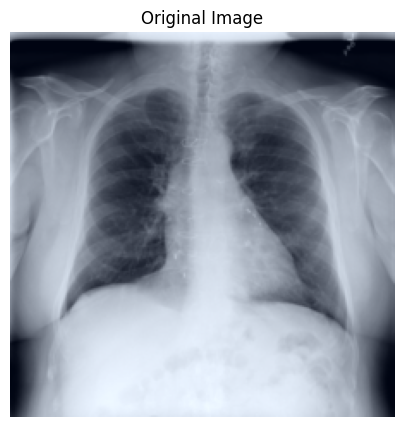

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0296907].


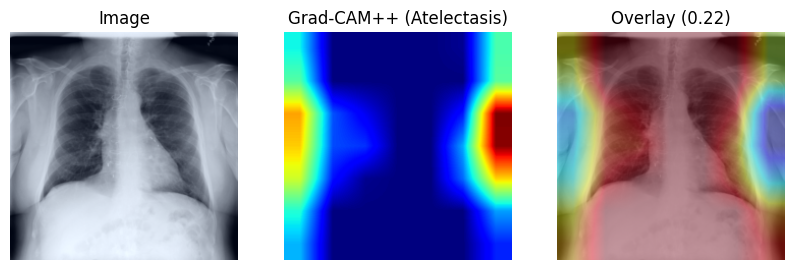

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0296907].


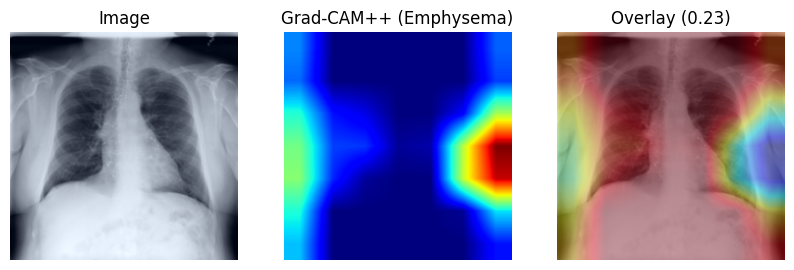

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0296907].


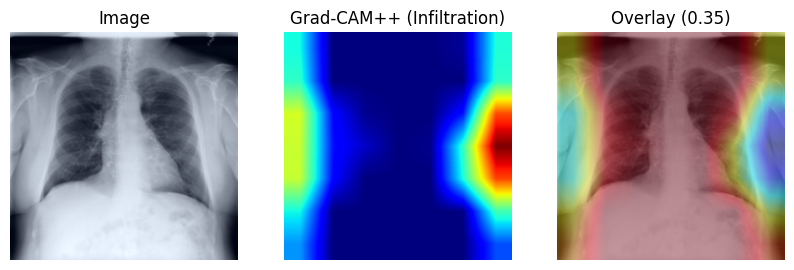

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0296907].


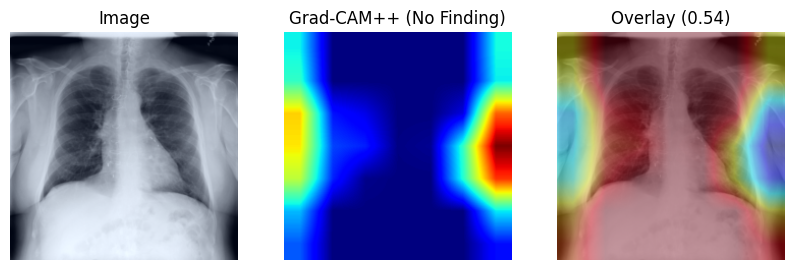

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0296907].


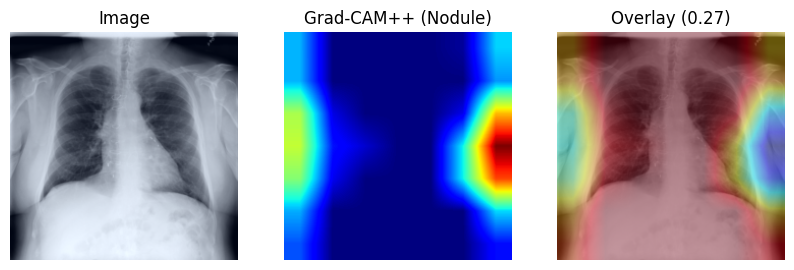

In [126]:
image, true_label = val_dataset[0]

model.eval()
output = model(image.unsqueeze(0).to(device))
probs = torch.sigmoid(output)[0].detach().cpu().numpy()

show_predictions_with_gradcam(image, true_label.numpy(), probs, threshold=0.2)